<a href="https://colab.research.google.com/drive/1f6_Zdg83coF6hmrhNZkYmgretR3HICKw"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6 - Tree-based Methods - Homework by Łukasz Grzegrzółka

### Original notebook author: Szymon Nowakowski

# **Homework Assignment: Understanding Splitting Criteria in CART for Regression**
---------------------

In this assignment, you will explore three common formulations of the splitting criterion used in **CART (Classification and Regression Trees)** for **regression problems**:

1. **Local RSS Minimization**  
2. **RSS Gain Maximization**  
3. **Total RSS Minimization**

You will investigate whether any of these criteria are equivalent, and you will design an experiment to determine which criterion is actually employed in a standard implementation such as **scikit-learn’s DecisionTreeRegressor**.



## **The Problem**

Many treatments of CART for regression describe the split selection process in different ways. Below are three frequently cited formulations. Suppose we have a dataset with features $X$ and target $y$, and we have a partially built tree $T$. We seek to choose the next region (denoted `Parent` in what follows) to split: the feature $X_j$ and the threshold $t$ to split the data into two child regions $R_1(X_j, t)$ and $R_2(X_j, t)$. Denote by $\bar{y}_{R_m}$ the mean of targets within region $R_m$, with $m=1,2$.

1. **Local RSS Minimization**  
   We select the `Parent`, the feature and threshold that minimize the **sum of squared errors** in the two resulting child nodes:
   $$
   (Parent^*, X_j^*, t^*) = \text{argmin}_{Parent, X_j, t} \sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2.
   $$

2. **RSS Gain Maximization**  

   It is also a local method, looking only at a `Parent` and two child nodes.

   We select the `Parent`, the feature and threshold that maximize the **reduction** in RSS, computed by subtracting the RSS of the two child nodes from the RSS in the parent node:
   $$
   (Parent^*, X_j^*, t^*) = \text{argmax}_{Parent, X_j, t} \Bigl\{
   \underbrace{\sum_{i : x_i \in \text{Parent}} (y_i - \bar{y})^2}_{\text{Parent RSS}}
   \;-\;
   \underbrace{\sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2}_{\text{Children RSS}}
   \Bigr\}.
   $$

3. **Total RSS Minimization**  

   This formulation need somewhat more formal treatment.

   For a dataset $\{(x_i, y_i)\}_{i=1}^N$ with features $X$ and target $y$, let $T$ be the current tree.

   For any split of leaf $P$ on feature $X_j$ at threshold $t$, define $T(P, X_j, t)$ as the new tree obtained by splitting leaf $P$ of $T$ into two leaves $R_1(X_j, t)$ and $R_2(X_j, t)$.
   
   Let $\mathrm{Leaves}(T(P, X_j, t))$ be the set of all leaf indices in this new tree. For each leaf $m \in \mathrm{Leaves}(T(P, X_j, t))$, define:
   $$
   R_m = \{\, i \,\mid\, x_i \text{ ends in leaf } m\}.
   $$

   $R_m$ set collects all data indices $i$ whose feature vector $x_i$ is classified into the leaf node $m$ when passed through the tree $T(P, X_j,t)$. In other words, each leaf node $m$ in $T(P, X_j, t)$ corresponds to a unique path of splits, and any data point $x_i$ that follows that path is assigned to the leaf $m$; hence, it belongs to $R_m$.

   $R_m$ sets for all leafs $m \in \mathrm{Leaves}(T(X_j, t))$ define a partition of all indices.

   Then the objective of **minimizing total Residual Sum of Squares (total RSS)** is stated as:
   $$
   (P^*, X_j^*, t^*) = \text{argmin}_{P, X_j, t} \sum_{m \in \mathrm{Leaves}(T(P, X_j, t))}
   \sum_{i \in R_m} \Bigl(y_i - \overline{y}_{R_m}\Bigr)^2,
   $$
   where
   $$
   \overline{y}_{R_m} = \frac{1}{\lvert R_m \rvert}
   \sum_{i \in R_m} y_i
   $$
   is the mean response in leaf $m$.


## **Research Questions**

1. **Equivalence Analysis**  
   Determine whether the above formulations are equivalent or if they can yield different split choices. Specifically:
   - Are *local RSS minimization* and *RSS gain maximization* equivalent?
   - Does *total RSS minimization* coincide with either of these two, or is it distinct?
   
2. **Empirical Experiment**  
   Design and conduct a Python experiment to determine which of these formulations is implemented in `scikit-learn` in `DecisionTreeRegressor`. Present numerical results and plots to support your conclusion.

   **Hint:** consider finding an argument to `DecisionTreeRegressor` or its training routine that will stop the construction process at a well selected moment, so you can inspect those results and see which algorithm was chosen. Using in-class terminology it is a **pre-prunning** type of regularization.

## **Tasks & Deliverables**

1. **Formulation Analysis**  
   - Compare *local RSS minimization*, *RSS gain maximization*, and *total RSS minimization*.
   - If you find that any pair of formulations is equivalent, provide a concise proof.  
   - If you find that they differ, construct a counterexample.

2. **Empirical Verification**  
   - Create a small artificial dataset and train a `DecisionTreeRegressor` from `scikit-learn`.
   - The dataset must be designed in a way that uniquely identifies the formulation used. Provide a short code snippet and a plot or table to support your conclusion.

3. **Report**  
   - Summarize your theoretical insights and empirical findings in a **Colab notebook**.
   - Include the relevant proofs, code, discussion, and conclusions.
   - Place the notebook in your **GitHub repository** for this course, add a link to it in your README.md and add an **“Open in Colab”** badge in the notebook so it can be launched directly.



## Porównanie *Local RSS Minimization* oraz *RSS Gain Maximization*

W celu sprawdzenia, czy *Local RSS Minimization* oraz *RSS Gain Maximization* są równoważne, analizujemy dwa zbiory:

- **Parent A:** \([-15, -10, 10, 15]\)
- **Parent B:** \([80, 90, 110, 120]\)

Dla uproszczenia przyjmijmy, że dane mają tylko jedną cechę $X$ oraz dla każdego elementu $i$ jego wartość targetu jest równa wartości cechy, czyli $X_i = y_i$.
Dla każdego Parent rozważamy wszystkie możliwe progi \(t\) pomiędzy kolejnymi punktami.

---

## 1. Obliczenia dla Parent A

Dane:  


$
[-15, -10, 10, 15], \quad \bar y_A = 0, \quad RSS_A = 650
$



Możliwe progi:
- $(t_1 = -12.5)$
- $(t_2 = 0)$
- $(t_3 = 12.5)$

### Wyniki:

| Split \(t\) | Children RSS | RSS Gain |
|-------------|--------------|----------|
| \(-12.5\)   | \(350\)      | \(300\)  |
| \(0\)       | **25**       | **625**  |
| \(12.5\)    | \(350\)      | \(300\)  |

**Najlepszy split (A):**  
- Minimalne RSS_children = **25**  
- Maksymalny gain = **625**  
- Obydwa kryteria wskazują split w \(t = 0\)

---

## 2. Obliczenia dla Parent B

Dane:  


$
[80, 90, 110, 120], \quad \bar y_B = 100, \quad RSS_B = 1000
$



Możliwe progi:
- $(t_1 = 85)$
- $(t_2 = 100)$
- $(t_3 = 115)$

### Wyniki:

| Split \(t\) | Children RSS | RSS Gain |
|-------------|--------------|----------|
| \(85\)     | $(\approx 466.67)$ | $(\approx 533.33)$ |
| \(100\)       | **100**      | **900**  |
| \(115\)      | $(\approx 466.67)$ | $(\approx 533.33)$ |

**Najlepszy split (B):**  
- Minimalne RSS_children = **100**  
- Maksymalny gain = **900**  
- Obydwa kryteria wskazują split w \(t = 100\)

---

## 3. Porównanie Parent A i Parent B

Teraz porównujemy najlepsze możliwe splity dla obu Parentów:

| Parent | Minimalne RSS_children | Maksymalny RSS Gain |
|--------|-------------------------|----------------------|
| A      | **25**                 | 625                  |
| B      | 100                    | **900**              |

### Wnioski:

- **Local RSS Minimization** wybiera Parent **A**, ponieważ:
  

$25 < 100$

- **RSS Gain Maximization** wybiera Parent **B**, ponieważ:
  
$900 > 625$



---

## 4. Konkluzja

Dla uprzednio *ustalonego Parent* oba kryteria są równoważne, ponieważ:

$
\arg\min RSS_{children} \equiv \arg\max (RSS_{parent} - RSS_{children})
$,

czyli jeżeli *Parent* jest ustalony, to $RSS_{parent}$ jest stałym parametrem, czyli minimalizacja $RSS_{children}$ jednocześnie będzie prowadzić do maksymalizacji RSS gain.



Jednak gdy definicja dopuszcza jednoczesny wybór **(Parent, X_j, t)**, tak jak w rozważanych wzorach:



$
(Parent^*, X_j^*, t^*) = \arg\min RSS_{children}
$




$
(Parent^*, X_j^*, t^*) = \arg\max (RSS_{parent} - RSS_{children})
$



to **kryteria nie są równoważne**.

Powyższy przykład stanowi **kontrprzykład**, w którym oba kryteria wybierają różne Parenty, ponieważ Parent B ma większy $RSS_{parent}$, co zwiększa jego RSS gain, mimo że Parent A ma mniejsze $RSS_{children}$.



## Analiza kryterium *Total RSS Minimization* oraz jego relacji do pozostałych kryteriów

Kryterium **Total RSS Minimization** opisuje jako cel minimalizację całkowitej sumy kwadratów reszt w całym drzewie po wykonaniu pojedynczego splitu.

### Definicja

Niech \(T\) będzie aktualnym drzewem, a \(P\) — jednym z jego liści.  
Rozważamy split liścia \(P\) według cechy ($X_j$) i progu ($t$), co prowadzi do powstania dwóch nowych liści:



$
R_1(P, X_j, t), \quad R_2(P, X_j, t).
$



Po wykonaniu splitu otrzymujemy nowe drzewo ($T(P, X_j, t)$).  
Jego całkowity RSS definiujemy jako:



$
\text{Total RSS}(T(P, X_j, t)) =
\sum_{m \in \mathrm{Leaves}(T(P, X_j, t))}
\sum_{i \in R_m} (y_i - \bar y_{R_m})^2.
$



### Kluczowa obserwacja

Po rozcięciu liścia \(P\):

- wszystkie **inne liście drzewa pozostają niezmienione**,  
- jedyną częścią zależną od splitu są **dwa nowe liście** powstałe z \(P\).

Dlatego:



$
\text{Total RSS}(T(P, X_j, t)) =
\underbrace{\sum_{\text{inne liście}} RSS}_{\text{stałe}}
+
RSS(R_1) + RSS(R_2).
$



Oznacza to, że **minimalizacja total RSS jest równoważna minimalizacji RSS dzieci**, o ile liść \(P\) jest ustalony.

---

## Równoważność przy ustalonym Parent

Jeżeli rozważamy split **konkretnego** liścia \(P\), to:



$
\arg\min_{X_j,t} \text{Total RSS}(T(P, X_j, t))
\equiv
\arg\min_{X_j,t} (RSS(R_1) + RSS(R_2)).
$



To jest dokładnie kryterium **Local RSS Minimization**.

Ponadto:



$
RSS_{parent}(P) = \text{const},
$



więc:



$
\arg\min RSS_{children}
\equiv
\arg\max (RSS_{parent} - RSS_{children}),
$



czyli równoważne jest również **RSS Gain Maximization**.

**Wniosek:**  
Dla ustalonego Parent wszystkie trzy kryteria są równoważne.

---

## Brak równoważności przy jednoczesnym wyborze Parent, cechy i progu

W definicji zadanej w treści:



$
(P^*, X_j^*, t^*) = \arg\min_{P, X_j, t} \text{Total RSS}(T(P, X_j, t)),
$



czyli wybieramy:

- który liść ($P$) rozciąć,
- cechę ($X_j$),
- próg ($t$).

Wtedy:



$
\text{Total RSS}(T(P, X_j, t)) =
\underbrace{\sum_{\text{inne liście}} RSS}_{\text{różne dla różnych Parentów}}
+
RSS_{children}(P, X_j, t)=
\underbrace{\sum_{\text{Wszystkie liście przed podziałem}} RSS}_{\text{const}} - RSS_{parent}(P)
+
RSS_{children}(P, X_j, t).
$



Wkład „innych liści” zależy od tego, **który Parent wybierzemy**, ponieważ każdy Parent ma inne ($RSS_{parent}$).

To prowadzi do dwóch ważnych konsekwencji:

1. **Total RSS minimization faworyzuje Parent o dużym $RSS_{parent}$**, ponieważ jego rozcięcie najbardziej zmniejsza total RSS.

2. Jest to dokładnie to samo zachowanie, co w **RSS Gain Maximization**, gdzie gain = ($RSS_{parent} - RSS_{children}$).

Natomiast **Local RSS Minimization** patrzy wyłącznie na ($RSS_{children}$), więc może wybrać Parent o małym RSS_parent.

---

## Ostateczny wniosek

| Kryterium | Ustalony Parent | Parent wybierany razem ze splitem |
|-----------|------------------|-----------------------------------|
| Local RSS Minimization | równoważne RSS gain i total RSS | **różne** od RSS gain i total RSS |
| RSS Gain Maximization | równoważne local RSS i total RSS | równoważne total RSS |
| Total RSS Minimization | równoważne local RSS i gain | **równoważne RSS gain**, różne od local RSS |

**Total RSS Minimization jest równoważne pozostałym kryteriom tylko wtedy, gdy Parent jest ustalony, ale wtedy wszystkie metody działałyby tylko lokalnie, więc chyba nie jest to właściwe podejście do holistycznej optymalizacji drzewa.  
Gdy Parent jest wybierany jednocześnie ze splitem, total RSS minimization zachowuje się tak samo jak RSS gain, a inaczej niż local RSS minimization.**

## 2. Experimental analysis with `DecisionTreeRegressor`

W celu sprawdzenia, którego kryterium używa `DecisionTreeRegressor` ze `scikit-learn`, posłużymy się przykładem zbioru omawianego już poprzednio, w kórym mamy 8 elementów o tylko jednej cesze $X$ i o wartości targetu $y$ równej wartości cechy $X$. Zbiór elementów naturalnie dzieli się na dwa czteroelementowe zbiory, skupione wokół 0 i 100. Są to te same zbiory, kóre wcześniej omawialiśmy podczas rozważania równoważności Local RSS minimization i RSS Gain maximization. Tworzymy następnie drzewo decyzyjne na takim zbiorze, ograniczając liczbę liści do 3. Pierwszy podział oczywiście dzieli cały zbiór na dwa dobrze odseparowane podzbiory, te same które poprzednio oznaczyliśmy jako Parent A i Parent B. Teraz następuje drugi podział, kóry jet kluczowy dla naszego eksperymentu. Zgodnie z wnioskami z części pierwszej, podejścia RSS Gain maximization i Total RSS minimization są równoważne, zatem istnieją dwie możliwości sposobu dokonania następnego podziału. Jeżeli `DecisionTreeRegressor` stosuje podejście Local RSS minimization, podzielony zostanie Parent A, skupiony wokół $X = 0$. Alternatywnie, jeżeli stosowanym podejściem jest RSS Gain maximization, podzielony zostanie podzbiór Parent B, skupiony wokół $X = 100$.

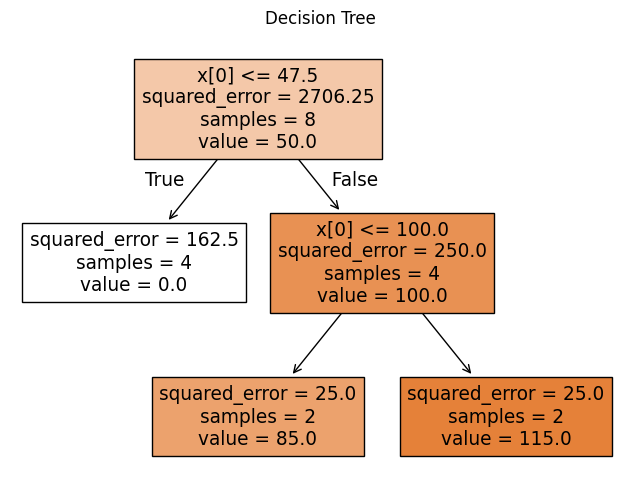

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

X = np.array([-15, -10, 10, 15, 80, 90, 110, 120]).reshape(-1, 1)
y = X.copy()

tr = DecisionTreeRegressor(max_leaf_nodes=3)
tr.fit(X, y)

# Plot the full tree
plt.figure(figsize=(8, 6))
plot_tree(
    tr,
    filled=True
)
plt.title("Decision Tree")
plt.show()


Jak widzimy na powyższym schemacie, podzielony został zbiór Parent B, skupiony wokół $X = 100$, zatem `DecisionTreeRegressor` stosuje **RSS Gain maximization** podczas wyboru optymalnego sposobu wykonywania podziału.